# Library

In [1]:
import pandas as pd
import re
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

import os
import string
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
from styleframe import StyleFrame
from IPython.display import display, HTML

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

# I need to see if timestamp data is compatible (how much is matched) and general statistics

In [5]:
# data with timing
dftime = pd.read_excel("otherData/fomcspeak_archive.xlsx")
print(dftime.shape)
dftime.head()

(4108, 5)


,author,context,date,url-title,url-href
0,Jerome H. Powell,"Speech, at “Structural Shifts in the Global Ec...","August 25, 2023 (10:05 AM ET)",Inflation: Progress and the Path Ahead,https://www.federalreserve.gov/newsevents/spee...
1,Patrick T. Harker,"Video Interview, CNBC, Philadelphia Fed Presid...","August 24, 2023 (10:47 AM ET)",Philadelphia Fed President Patrick Harker: We ...,https://www.cnbc.com/video/2023/08/24/philadel...
2,Michelle W. Bowman,"Opening Remarks, at “Fed Listens: Joining the ...","August 22, 2023 (02:30 PM ET)",Welcoming Remarks,https://www.federalreserve.gov/newsevents/spee...
3,Austan Goolsbee,"Opening Remarks, at “Fed Listens: Joining the ...","August 22, 2023 (02:00 PM ET)",Opening Remarks,https://www.chicagofed.org/publications/speech...
4,Patrick T. Harker,"Speech, at a Fed Communities Virtual Event in ...","August 10, 2023 (04:00 PM ET)",Worker Voices Show Us What the Data Do Not,https://www.philadelphiafed.org/community-deve...


In [6]:
# I need to check if ET is the only thing here:
print(dftime["date"].str.endswith(" ET)").all())

# the answer is no, so i need to see what else there are:
tzdiff = dftime[~dftime["date"].str.endswith(" ET)")]
print(tzdiff.shape)
tzdiff



False
(32, 5)


,author,context,date,url-title,url-href
8,Thomas I. Barkin,"Speech, at the Montgomery County Chamber of Co...","August 03, 2023",Recession Revisited,https://www.richmondfed.org/press_room/speeche...
12,Neel Kashkari,"Essay, Federal Reserve Bank of Minneapolis, Th...","July 12, 2023",The Interaction between Inflation and Financia...,https://www.minneapolisfed.org/article/2023/th...
32,Neel Kashkari,"Essay, Federal Reserve Bank of Minneapolis, Do...","May 22, 2023",Doubling Down on Wisdom Is an Illusory Solution,https://www.minneapolisfed.org/article/2023/do...
78,Raphael Bostic,"Essay, Federal Reserve Bank of Atlanta, Striki...","March 01, 2023",Striking a Delicate Balance in Making Policy,https://www.atlantafed.org/about/atlantafed/of...
115,Neel Kashkari,"Essay, at the Federal Reserve Bank of Minneapo...","January 4, 2023","Why We Missed On Inflation, and Implications f...",https://www.minneapolisfed.org/article/2023/wh...
116,Mary C. Daly,"Blog Post, at the Federal Reserve Bank San Fra...","December 19, 2022",How your insights help us at the Federal Reserve,https://fedcommunities.org/how-your-insights-h...
117,Loretta J. Mester,"Essay, at the Federal Reserve Bank of Clevelan...","December 16, 2022",Reflections: Now Is the Time to Close the Digi...,https://www.clevelandfed.org/collections/essay...
137,Raphael Bostic,"Essay, Federal Reserve Bank of Atlanta, On Lon...","November 15, 2022",On Long and Variable Lags in Monetary Policy,https://www.atlantafed.org/about/atlantafed/of...
163,Neel Kashkari,"Essay, Federal Reserve Bank of Minneapolis, Re...","October 05, 2022",Reflection: Five Years of Equipping Policymake...,https://www.minneapolisfed.org/article/2022/re...
164,John C. Williams,"Blog Post, Federal Reserve Bank of St. Louis, ...","October 05, 2022",Measuring the Ampleness of Reserves,https://libertystreeteconomics.newyorkfed.org/...


In [7]:
# Now to parse the date
dftime["dateOnly"] = pd.to_datetime(dftime["date"].str.extract(r"^([A-Za-z]+\s+\d{1,2},\s+\d{4})")[0])

# for the time part
dftime["time"] = dftime["date"].str.extract(r"\((.*?)\)")  # gets things inside the parenthesis if any, otherwise empty
dftime["timeOnly"] = pd.to_datetime(
    dftime["time"].str.replace(" ET", "", regex=False),
    format="%I:%M %p",
    errors="coerce"
).dt.time

# checking the missing values
print(dftime["dateOnly"].isnull().sum())
print(dftime["timeOnly"].isnull().sum())

# drop the unnecessary columns
dftime = dftime.drop(columns = ["date","time"])

0
32


In [8]:
# other stuffs
# minimum and maximum time
minTime = dftime["dateOnly"].min()
maxTime = dftime["dateOnly"].max()
print(minTime)
print(maxTime)


2010-08-26 00:00:00
2023-08-25 00:00:00


In [9]:
# This is to remove "duplicates" (ex, video vs remark same events)
dftime = (
    dftime
    .sort_values(["author", "dateOnly"])  # optional
    .groupby(["author", "dateOnly", "url-title"], as_index=False)
    .first()  # keep the first row
)

print(dftime.shape)
dftime.head()


(4042, 6)


,author,dateOnly,url-title,context,url-href,timeOnly
0,.,2022-07-27,Transcript of Chair Powell's Press Conference ...,"Transcript, Federal Reserve Board of Governors...",https://www.federalreserve.gov/mediacenter/fil...,13:30:00
1,Austan Goolsbee,2023-02-28,The Need for a Ground-Level View of the Economy,"Remarks, at the Ivy Tech Community College, El...",https://www.chicagofed.org/publications/speech...,14:30:00
2,Austan Goolsbee,2023-04-11,Monetary Policy in Moments of Financial Uncert...,"Remarks, at the Economic Club of Chicago Forum...",https://www.chicagofed.org/publications/speech...,13:30:00
3,Austan Goolsbee,2023-08-22,Opening Remarks,"Opening Remarks, at “Fed Listens: Joining the ...",https://www.chicagofed.org/publications/speech...,14:00:00
4,Ben S. Bernanke,2010-08-27,The Economic Outlook and Monetary Policy,"Speech, The Federal Reserve Bank of Kansas Cit...",http://www.federalreserve.gov/newsevents/speec...,00:00:00


In [10]:
# just a quick check on name
# missing name?
print(dftime["author"].isna().sum())
# 1 word speaker name?
print(dftime[dftime["author"].str.split().str.len() <= 1]["author"].unique())


0
['.']


In [11]:
# what is that weird dot
dftime.loc[dftime["author"] == ".", "author"] = "Jerome Powell"
dftime.head()

,author,dateOnly,url-title,context,url-href,timeOnly
0,Jerome Powell,2022-07-27,Transcript of Chair Powell's Press Conference ...,"Transcript, Federal Reserve Board of Governors...",https://www.federalreserve.gov/mediacenter/fil...,13:30:00
1,Austan Goolsbee,2023-02-28,The Need for a Ground-Level View of the Economy,"Remarks, at the Ivy Tech Community College, El...",https://www.chicagofed.org/publications/speech...,14:30:00
2,Austan Goolsbee,2023-04-11,Monetary Policy in Moments of Financial Uncert...,"Remarks, at the Economic Club of Chicago Forum...",https://www.chicagofed.org/publications/speech...,13:30:00
3,Austan Goolsbee,2023-08-22,Opening Remarks,"Opening Remarks, at “Fed Listens: Joining the ...",https://www.chicagofed.org/publications/speech...,14:00:00
4,Ben S. Bernanke,2010-08-27,The Economic Outlook and Monetary Policy,"Speech, The Federal Reserve Bank of Kansas Cit...",http://www.federalreserve.gov/newsevents/speec...,00:00:00


In [16]:
# now importing main data and see which can merged (mostly author and date)
# since i only need to look at just the speaker, title, location, link, date, drop a lot of stuffs
df = pd.read_csv('FedSpeechesCleaned.csv', parse_dates = ['date'])
df = df[["District","title","speaker","location","date"]]
print(df.shape)
dfbackup = df.copy()
df.head()


(7239, 5)


,District,title,speaker,location,date
0,Boston,Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",2025-06-25
1,Boston,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,2024-09-30
2,Boston,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",2024-06-18
3,Boston,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",2024-05-08
4,Boston,Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,2024-04-16


In [17]:
# I want to check if the main dataset has multiple titles per speaker+date
title_conflicts = (
    df.groupby(["speaker", "date"])["title"]
           .nunique()
           .reset_index()
)

title_conflicts = title_conflicts[title_conflicts["title"] > 1]
print(title_conflicts.shape)
title_conflicts



(69, 3)


,speaker,date,title
23,Alan Greenspan,1988-06-14,2
40,Alan Greenspan,1989-02-23,2
162,Alan Greenspan,1995-01-25,2
163,Alan Greenspan,1995-01-26,2
248,Alan Greenspan,1997-10-14,2
...,...,...,...
6827,William C. Dudley,2012-03-19,2
6869,William C. Dudley,2014-10-20,2
6905,William C. Dudley,2016-07-31,2
6919,William C. Dudley,2017-03-21,2


In [25]:
# I need to see if the name is not matched because format problem or because they are not there.
# first just do a very basic dumping down format first and match to the best of it
# date and name alone not cutting it (people speaking twice a day; not all different 
# name + speaker has same default time.
df = dfbackup.copy()
def cleanName(name):
    if pd.isna(name):
        return ""
    
    name = name.lower().strip()
    name = re.sub(r"[.,]", "", name)          # remove punctuation
    name = re.sub(r"\b[a-z]\b", "", name)     # remove middle initials
    name = re.sub(r"\s+", " ", name)          # collapse whitespace
    
    # convert "last first" if comma was removed
    parts = name.split()
    if len(parts) == 0:
        return ""
    elif len(parts) == 1:
        return parts[0]
    elif len(parts) == 2:
        # assume "first last" is correct
        return f"{parts[0]} {parts[1]}"
    else:
        # if more than 2 parts, keep first and last only
        return f"{parts[0]} {parts[-1]}"
    
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r"\s+", " ", s)       
    s = re.sub(r"[^a-z0-9 ]", "", s)
    return s.strip()

df["title"] = df["title"].apply(normalize_title)
dftime["title"]   = dftime["url-title"].apply(normalize_title)

df["name"] = df["speaker"].apply(cleanName)
dftime["name"] = dftime["author"].apply(cleanName)

df = df.rename(columns = {"date":"dateOnly"})
print("total observation: " + str(df.shape))
dfmain = df[(df["dateOnly"] >= minTime) & (df["dateOnly"] <= maxTime)]
print("after restricting date: "+ str(dfmain.shape)) 

# merge and see
merged = dfmain.merge(
    dftime[["name", "dateOnly", "timeOnly","context","title"]],
    on=["name", "dateOnly","title"],
    how="left"
)

total observation: (7239, 6)
after restricting date: (2625, 6)


In [26]:
# checking the merged
print(merged.shape)
merged.head()


(2625, 8)


,District,title,speaker,location,dateOnly,name,timeOnly,context
0,BoardGovernors,the economic outlook and monetary policy,Ben S Bernanke,Board of Governors of the Federal Reserve,2010-08-27,ben bernanke,00:00:00,"Speech, The Federal Reserve Bank of Kansas Cit..."
1,BoardGovernors,stabilizing neighborhoods lessons learned fro...,Elizabeth A Duke,Board of Governors of the Federal Reserve,2010-09-01,elizabeth duke,NaN,NaN
2,NewYork,too big to fail expectations and impact of ex...,Thomas C Baxter,Federal Reserve Bank of New York,2010-09-01,thomas baxter,NaN,NaN
3,BoardGovernors,comments on regulating the shadow banking system,Daniel K Tarullo,Board of Governors of the Federal Reserve,2010-09-17,daniel tarullo,NaN,NaN
4,BoardGovernors,implications of the financial crisis for econo...,Ben S Bernanke,Board of Governors of the Federal Reserve,2010-09-24,ben bernanke,00:00:00,"Speech, The Conference Co-sponsored by the Cen..."


## Continue with checking the integrity of the data

In [31]:
# check to make sure that is there might be possibility of duplicate making up for non-match 
# (for instance, only 90% is matched but 10% markup due to duplicates, something like that)
unmatched = merged[merged["timeOnly"].isna()]
len(unmatched)


1068

In [33]:
# how many matches each main row received
match_counts = (
    merged.groupby(["name", "dateOnly", "title"], as_index=False)
          .size()
          .rename(columns={"size": "n_matches"})
)

match_counts["n_matches"].value_counts()


n_matches
1    2625
Name: count, dtype: int64

In [35]:
# ok so the problem is a lot of them is not matched
# we start with checking, for each speaker and date that is unmatch
# does the dftime has them or actually no
unmatched_keys = unmatched[["name", "dateOnly"]].drop_duplicates()

coverage = unmatched_keys.merge(
    dftime[["name", "dateOnly"]].drop_duplicates(),
    on=["name", "dateOnly"],
    how="left",
    indicator=True
)

coverage["_merge"].value_counts()


_merge
left_only     580
both          481
right_only      0
Name: count, dtype: int64

so a substantial amount of observation (580) does not have info

In [38]:
problem_cases = dfmain.merge(
    dftime,
    on=["name", "dateOnly"],
    how="inner",
    suffixes=("_main", "_ts")
)

problem_cases = problem_cases[
    problem_cases["title_main"] != problem_cases["title_ts"]
]

print(problem_cases.shape)
problem_cases.head()

(678, 12)


,District,title_main,speaker,location,dateOnly,name,author,url-title,context,url-href,timeOnly,title_ts
1,BoardGovernors,stabilizing neighborhoods lessons learned fro...,Elizabeth A Duke,Board of Governors of the Federal Reserve,2010-09-01,elizabeth duke,Elizabeth A. Duke,Stabilizing Neighborhoods: Lessons Learned fro...,"Speech, The Federal Reserve REO and Vacant Pro...",http://www.federalreserve.gov/newsevents/speec...,00:00:00,stabilizing neighborhoods lessons learned from...
2,BoardGovernors,comments on regulating the shadow banking system,Daniel K Tarullo,Board of Governors of the Federal Reserve,2010-09-17,daniel tarullo,Daniel K. Tarullo,Regulating the Shadow Banking System,"Comments, The Brookings Panel on Economic Acti...",http://www.federalreserve.gov/newsevents/speec...,00:00:00,regulating the shadow banking system
4,BoardGovernors,opening remarks at the public hearing on poten...,Elizabeth A Duke,Board of Governors of the Federal Reserve,2010-09-24,elizabeth duke,Elizabeth A. Duke,Home Mortgage Disclosure Act,"Opening Remarks, The Public Hearing on the Hom...",http://www.federalreserve.gov/newsevents/speec...,00:00:00,home mortgage disclosure act
5,BoardGovernors,regulatory reform implementation,Ben S Bernanke,Board of Governors of the Federal Reserve,2010-09-30,ben bernanke,Ben S. Bernanke,Importance of Economic Education,"Welcoming Remarks, The Federal Reserve System ...",http://www.federalreserve.gov/newsevents/speec...,00:00:00,importance of economic education
11,Kansas,the federal reserves mandate long run,Thomas M. Hoenig,Federal Reserve Bank of Kansas City,2010-10-12,thomas hoenig,Thomas Hoenig,The Federal Reserve's Mandate: Long Run,"Speech, National Association of Business Econo...",https://www.kansascityfed.org/~/media/files/pu...,00:00:00,the federal reserves mandate long run


# Now the shenanigan to fuzzy match and merge back to the main

## The fuzzy match

In [40]:
# match fuzzy
from rapidfuzz import process, fuzz

results = []

for (name, date), group in dfmain.groupby(["name", "dateOnly"]):
    
    # candidate titles from timestamp dataset for SAME speaker + date
    ts_titles = dftime.loc[
        (dftime["name"] == name) &
        (dftime["dateOnly"] == date),
        "title"
    ].unique()
    
    # if no timestamp titles exist → skip
    if len(ts_titles) == 0:
        continue
    
    for title_main in group["title"].unique():
        match, score, _ = process.extractOne(
            title_main,
            ts_titles,
            scorer=fuzz.token_sort_ratio
        )
        results.append([name, date, title_main, match, score])

fuzzy_matches = pd.DataFrame(results, columns=[
    "name", "dateOnly", "title_main", "title_ts", "score"
])

In [41]:
print(fuzzy_matches.shape)
fuzzy_matches.head()

(2042, 5)


,name,dateOnly,title_main,title_ts,score
0,austan goolsbee,2023-02-28,ivy tech community college,the need for a groundlevel view of the economy,33.333333
1,austan goolsbee,2023-04-11,economic club of chicago forum,monetary policy in moments of financial uncert...,34.567901
2,austan goolsbee,2023-08-22,fed listens joining the labor force after covi...,opening remarks,23.157895
3,ben bernanke,2010-08-27,the economic outlook and monetary policy,the economic outlook and monetary policy,100.000000
4,ben bernanke,2010-09-24,implications of the financial crisis for econo...,implications of the financial crisis for econo...,100.000000


(array([   2.,    3.,    5.,    4.,    7.,    8.,    7.,   13.,   13.,
          12.,   11.,   10.,    9.,   10.,    7.,   10.,    3.,   20.,
           4.,    4.,   10.,    2.,    9.,    7.,    4.,    7.,    5.,
          11.,    9.,   15.,   13.,   18.,   19.,   24.,   14.,   14.,
           3.,   10.,    4., 1682.]),
 array([ 15.58441558,  17.69480519,  19.80519481,  21.91558442,
         24.02597403,  26.13636364,  28.24675325,  30.35714286,
         32.46753247,  34.57792208,  36.68831169,  38.7987013 ,
         40.90909091,  43.01948052,  45.12987013,  47.24025974,
         49.35064935,  51.46103896,  53.57142857,  55.68181818,
         57.79220779,  59.9025974 ,  62.01298701,  64.12337662,
         66.23376623,  68.34415584,  70.45454545,  72.56493506,
         74.67532468,  76.78571429,  78.8961039 ,  81.00649351,
         83.11688312,  85.22727273,  87.33766234,  89.44805195,
         91.55844156,  93.66883117,  95.77922078,  97.88961039,
        100.        ]),
 <BarContainer

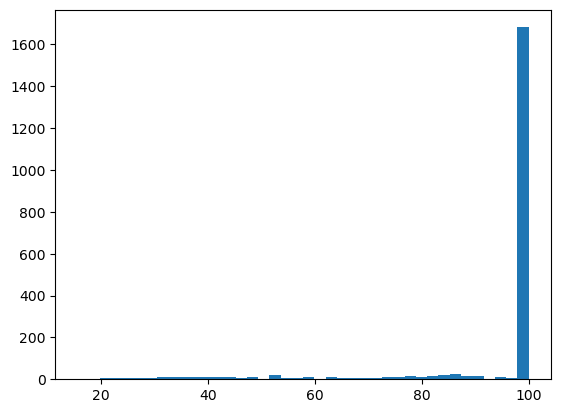

In [42]:
plt.hist(fuzzy_matches["score"], bins = 40)

In [46]:
# thoses with score >90 should be automatically good
# manually inspect those form 70-90
# the rest is not worth it

# TURNS OUT IT IS NOT NEEDED, IT IS VERY MUCH GOOD BC MATCHES IS CONSTRAIN
# WITHIN THE SPEAKER DATE PAIRS SO I DO score merge too
# gray = fuzzy_matches[(fuzzy_matches["score"] >= 70) & (fuzzy_matches["score"] < 90)]
# print(gray.shape)
# fuzzy_matches = fuzzy_matches.sort_values("score", ascending=False)

# fuzzy_matches["manual_decision"] = None
# fuzzy_matches["manual_decision"] = (fuzzy_matches["score"]>90).astype(int)
# fuzzy_matches.to_csv("manual_review_needed.csv", index=False)

In [159]:
# # after inspecting:
# manual = pd.read_csv("manual_review_done.csv")

# fuzzy_matches = manual[manual["manual_decision"] == 1]
# print(fuzzy_matches.shape)

## Now we try to merge back to main

In [46]:
# try to back to my main
print(dftime.shape)
print(fuzzy_matches.shape)
fuzzy_with_time = fuzzy_matches.merge(
    dftime[["name", "dateOnly", "title", "timeOnly"]],
    left_on=["name", "dateOnly", "title_ts"],
    right_on=["name", "dateOnly", "title"],
    how="left"
)
print(fuzzy_with_time.shape)
print(fuzzy_with_time.columns.tolist())

(4042, 8)
(2042, 5)
(2042, 7)
['name', 'dateOnly', 'title_main', 'title_ts', 'score', 'title', 'timeOnly']


In [48]:
dforiginal = pd.read_csv('FedSpeechesCleaned.csv', parse_dates = ['date'])
print(dforiginal.shape)

# i need to transform a few variables
dforiginal["title_main"] = dforiginal["title"].apply(normalize_title)
dforiginal["name"] = dforiginal["speaker"].apply(cleanName)
dforiginal["dateOnly"] = dforiginal["date"]

# now merge
dffinal = dforiginal.merge(
    fuzzy_with_time[["name", "dateOnly", "title_main", "timeOnly","score"]],
    on=["name", "dateOnly", "title_main"],
    how="left"
)
print(dffinal.shape) # need to be the same as the og!
dffinal.head()

(7239, 78)
(7239, 83)


,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,first_order_coherence,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score
0,Boston,0.0,False,False,"Economic Resilience, Amid Elevated Tariffs and...",Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",https://www.bostonfed.org/news-and-events/spee...,2025-06-25,...,0.526444,0.511636,4.969992,Not Board,True,perspectives on the economy from susan m collins,susan collins,2025-06-25,NaN,NaN
1,Boston,0.0,False,False,I am pleased to welcome all of you to the Fede...,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-09-30,...,0.387757,0.416154,5.349004,Not Board,True,welcoming remarks at the forum on meeting the ...,susan collins,2024-09-30,NaN,NaN
2,Boston,0.0,False,False,Takeaways from Boston Fed President Susan M. C...,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-06-18,...,0.381271,0.397782,4.661486,Not Board,True,a partnership for progress,susan collins,2024-06-18,NaN,NaN
3,Boston,0.0,False,False,Boston Fed President and CEO Susan M. Collins'...,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-05-08,...,0.452981,0.446677,4.695629,Not Board,True,reflections on uncertainty and patience in mon...,susan collins,2024-05-08,NaN,NaN
4,Boston,1.0,True,False,"hi, good afternoon everyone. my name is Beth B...",Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-04-16,...,0.375190,0.361304,5.368856,Not Board,True,remarks for the national association of corpor...,susan collins,2024-04-16,NaN,NaN


In [49]:
print(dffinal.columns.tolist())


['District', 'MultSpeakers', 'VideoForm', 'Article', 'content', 'title', 'speaker', 'location', 'link', 'date', 'positiveFin', 'neutralFin', 'negativeFin', 'hawkishMal', 'n_hawk_pair', 'n_dove_pair', 'concreteness', 'concretenessExtra', 'concreteRatio', 'concreteMean', 'concrete25', 'concreteMeanExtra', 'concrete25Extra', 'token_length_mean', 'token_length_median', 'token_length_std', 'sentence_length_mean', 'sentence_length_median', 'sentence_length_std', 'syllables_per_token_mean', 'syllables_per_token_median', 'syllables_per_token_std', 'n_tokens', 'n_unique_tokens', 'proportion_unique_tokens', 'n_characters', 'n_sentences', 'entropy', 'perplexity', 'per_word_perplexity', 'dependency_distance_mean', 'dependency_distance_std', 'prop_adjacent_dependency_relation_mean', 'prop_adjacent_dependency_relation_std', 'passed_quality_check', 'n_stop_words', 'alpha_ratio', 'mean_word_length', 'doc_length', 'symbol_to_word_ratio_#', 'proportion_ellipsis', 'proportion_bullet_points', 'contains_lo

In [50]:
dffinal.to_csv('FedSpeechesWithTime.csv', date_format='%Y-%m-%d %H:%M:%S', index = False)


# For now, only add PC and save the neccessary data only


In [77]:
df = pd.read_csv('FedSpeechesWithTime.csv', parse_dates = ['date','dateOnly'])
print(df.shape)
df.head()


(7239, 83)


,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,first_order_coherence,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score
0,Boston,0.0,False,False,"Economic Resilience, Amid Elevated Tariffs and...",Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",https://www.bostonfed.org/news-and-events/spee...,2025-06-25,...,0.526444,0.511636,4.969992,Not Board,True,perspectives on the economy from susan m collins,susan collins,2025-06-25,NaN,NaN
1,Boston,0.0,False,False,I am pleased to welcome all of you to the Fede...,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-09-30,...,0.387757,0.416154,5.349004,Not Board,True,welcoming remarks at the forum on meeting the ...,susan collins,2024-09-30,NaN,NaN
2,Boston,0.0,False,False,Takeaways from Boston Fed President Susan M. C...,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-06-18,...,0.381271,0.397782,4.661486,Not Board,True,a partnership for progress,susan collins,2024-06-18,NaN,NaN
3,Boston,0.0,False,False,Boston Fed President and CEO Susan M. Collins'...,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-05-08,...,0.452981,0.446677,4.695629,Not Board,True,reflections on uncertainty and patience in mon...,susan collins,2024-05-08,NaN,NaN
4,Boston,1.0,True,False,"hi, good afternoon everyone. my name is Beth B...",Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-04-16,...,0.375190,0.361304,5.368856,Not Board,True,remarks for the national association of corpor...,susan collins,2024-04-16,NaN,NaN


In [78]:
def bartlettSphericity(df, pthreshold = 0.05):
    chi_square_value, p_value = calculate_bartlett_sphericity(df)
    print("The p-value = "+ str(p_value))
    if p_value <pthreshold:
        print('Significant at 5%, the observered matrix is not an identity matrix')
    else:
        print('There are likely little correlation')
    return p_value

def getPC(df, varList, numComp):
    df = df.reset_index(drop=True)
    dfPrep = df[varList].copy()
    # need to drop missing value if any
    dfPrep = dfPrep.dropna()
    indexNonM = dfPrep.index.tolist()
    
    XScaled = StandardScaler().fit_transform(dfPrep.values)
    dfXScaled = pd.DataFrame(XScaled, index=dfPrep.index, columns=dfPrep.columns)
    
    pca = PCA(n_components=numComp)
    pca_features = pca.fit_transform(XScaled)
 
    pca_df = pd.DataFrame(
        data=pca_features, 
        columns=['PC'+str(i+1) for i in range(numComp)])
    pca_df.index = indexNonM
    
    res = df.join(pca_df)
    return res

def combineVar(df, varList, numComp, name, drop= True, printBartlett = True, printCorr = False, printMissing = False):
    if name in df.columns.tolist():
        df = df.drop(columns = [name])
    df0 = df[varList].copy()
    if printBartlett:
        bartP = bartlettSphericity(df0.dropna(), pthreshold = 0.05)
    if printMissing:
        print(df0.isnull().sum())

    df1 = getPC(df, varList, numComp)
    df1.rename(columns = {'PC1':name}, inplace = True)

    if printCorr:
        print(df1[varList+[name]].corr()[[name]])
    if drop:
        df1.drop(columns = varList, inplace = True)
    if printBartlett:
        return df1, bartP
    else:
        return df1



In [79]:
varMegaList = [['concreteness', 'concretenessExtra', 'concreteRatio', 'concreteMean', 'concrete25', 'concreteMeanExtra', 'concrete25Extra'],
               ['entropy'],
               ['flesch_reading_ease', 'flesch_kincaid_grade', 'smog', 'gunning_fog', 'automated_readability_index', 'coleman_liau_index', 'lix', 'rix'],
               ['first_order_coherence', 'second_order_coherence'],
               ['dependency_distance_mean'],
               ['upStrain']
              ]
allvar = varMegaList[0]
for i in varMegaList[1:]:
    allvar = allvar+i
nameList = ['abstract','info','read','disunity','strain','strainUpper']
df[allvar].isnull().sum()


concreteness                   0
concretenessExtra              0
concreteRatio                  0
concreteMean                   0
concrete25                     0
concreteMeanExtra              0
concrete25Extra                0
entropy                        0
flesch_reading_ease            0
flesch_kincaid_grade           0
smog                           0
gunning_fog                    0
automated_readability_index    0
coleman_liau_index             0
lix                            0
rix                            0
first_order_coherence          0
second_order_coherence         0
dependency_distance_mean       0
upStrain                       0
dtype: int64

In [80]:
dfPC = df.copy()

for var in [i for i in varMegaList[0] if i not in ['concreteRatio']]:
    dfPC[var+'flip'] = 6-dfPC[var]
dfPC['concreteRatioflip'] = 1/dfPC['concreteRatio'] #according to the summary stat, there is no 0
varMegaList[0] = [i+'flip' for i in varMegaList[0]]

numComp = 1
for i in range(len(nameList)):
    varList = varMegaList[i]
    name = nameList[i]
    print(name)
    if len(varList) == 1:
        dfPC = combineVar(dfPC, varList, numComp, name, drop= False, printBartlett = False, printCorr = False, printMissing = False)
    else:
        dfPC, pvalue = combineVar(dfPC, varList, numComp, name, drop= False, printBartlett = True, printCorr = True, printMissing = True)

# PC for readability suddenly side with the flesch reading ease so i have to flip the sign
dfPC['read'] = -dfPC['read']


abstract
The p-value = nan
There are likely little correlation
concretenessflip         0
concretenessExtraflip    0
concreteRatioflip        0
concreteMeanflip         0
concrete25flip           0
concreteMeanExtraflip    0
concrete25Extraflip      0
dtype: int64
                       abstract
concretenessflip       0.905866
concretenessExtraflip  0.794620
concreteRatioflip      0.815640
concreteMeanflip       0.905866
concrete25flip         0.905866
concreteMeanExtraflip  0.794620
concrete25Extraflip    0.794620
abstract               1.000000
info
read
The p-value = 0.0
Significant at 5%, the observered matrix is not an identity matrix
flesch_reading_ease            0
flesch_kincaid_grade           0
smog                           0
gunning_fog                    0
automated_readability_index    0
coleman_liau_index             0
lix                            0
rix                            0
dtype: int64
                                 read
flesch_reading_ease          0.998776

In [81]:
# simple correlations
mainVar = ['abstract','info','read','disunity','strain','strainUpper']
dfcheck = dfPC[mainVar]
with pd.option_context("display.max_columns", None):
    display(dfcheck.corr())
    

,abstract,info,read,disunity,strain,strainUpper
abstract,1.000000,0.100199,0.259049,0.274988,0.240660,0.116868
info,0.100199,1.000000,0.004177,0.103631,0.118767,0.183895
read,0.259049,0.004177,1.000000,0.669820,0.722843,0.492184
disunity,0.274988,0.103631,0.669820,1.000000,0.818451,0.376931
strain,0.240660,0.118767,0.722843,0.818451,1.000000,0.554012
strainUpper,0.116868,0.183895,0.492184,0.376931,0.554012,1.000000


In [82]:
# only keep some variables
dfPC = dfPC[['District', 'MultSpeakers', 'VideoForm', 'Article', 'title', 'speaker', 'location', 'date', 
             'positiveFin', 'neutralFin', 'negativeFin', 'hawkishMal', 'n_hawk_pair', 'n_dove_pair', 
             'board_role', 'IsBpres', 'timeOnly', 'score', 
             'abstract', 'info', 'read', 'disunity', 'strain', 'strainUpper']]
print(dfPC.shape)
dfPC.head()


(7239, 24)


,District,MultSpeakers,VideoForm,Article,title,speaker,location,date,positiveFin,neutralFin,...,board_role,IsBpres,timeOnly,score,abstract,info,read,disunity,strain,strainUpper
0,Boston,0.0,False,False,Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",2025-06-25,0.408672,0.320187,...,Not Board,True,NaN,NaN,-0.505043,-1.001508,0.549727,1.414322,1.248469,0.401612
1,Boston,0.0,False,False,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,2024-09-30,0.083191,0.874509,...,Not Board,True,NaN,NaN,-0.498079,-1.301498,0.136157,-0.782407,1.443697,0.986293
2,Boston,0.0,False,False,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",2024-06-18,0.327147,0.590322,...,Not Board,True,NaN,NaN,-1.150382,0.023803,-0.376274,-1.035339,-0.103317,-0.074304
3,Boston,0.0,False,False,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",2024-05-08,0.467524,0.391142,...,Not Board,True,NaN,NaN,-1.380554,0.407671,0.002579,0.095376,0.512876,-0.021633
4,Boston,1.0,True,False,Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,2024-04-16,0.228169,0.700974,...,Not Board,True,NaN,NaN,0.326771,8.158360,-1.688617,-1.480408,0.519999,1.016919


In [89]:
dfPC.to_csv('FedSpeechesPC.csv', date_format='%Y-%m-%d %H:%M:%S', index = False)
